# 3. Descriptive Statistics

**Shared pipeline:**
1. Summarize each metric for each participant (participant means)
2. Normality testing: this is to determine if we should use paired t-test or Wilcoxon sign rank, depending on normality
    a. Calculate pair-wise difference for each metric for each participant
    b. Shapiro-Wilk test
3. Paired tests (participant means)
4. Summarize each metric across all participant
5. Format result table for Latex

In [12]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/plot_helpers.R")
source("../util/descriptive_stats_helper.R")

AGGREGATION_PERIOD = "100 years" # bootstrap to average over entire dataset

## 3.1. Health metrics (treatment1 vs treatment2)

In [13]:
HEALTH_METRIC_WITH_EXPOSURE_DFS <- read_rds("../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")

HEALTH_METRIC_WITH_EXPOSURE <- bind_rows(HEALTH_METRIC_WITH_EXPOSURE_DFS) |> 
    filter(
        sample_type_id %in% HEALTH_METRICS
    ) |> 
    rename(type_id = location_type) |>
    select(pseudonym, type_id, sample_type_id, start_date, period_id, treatment, value)

# 1. Summarize each metric for each participant (participant means)
health_metric_summary_each_participant <- process_and_summarize_each_metric_each_participant(
    data = HEALTH_METRIC_WITH_EXPOSURE |> filter(sample_type_id != RHR), # RHR is across all location so it will be added below
    group_by_cols = c("pseudonym", "treatment", "type_id", "sample_type_id")
)

# Add a virtual flag for all location 
HEALTH_METRIC_WITH_EXPOSURE_ALL_LOCATION <- HEALTH_METRIC_WITH_EXPOSURE |>
    mutate(
        type_id = "all"
    )
health_metric_summary_each_participant_all_location <- process_and_summarize_each_metric_each_participant(
    data = HEALTH_METRIC_WITH_EXPOSURE_ALL_LOCATION,
    group_by_cols = c("pseudonym", "treatment", "type_id", "sample_type_id")
)

# Then join back to the original summary
health_metric_summary_each_participant <- bind_rows(
        health_metric_summary_each_participant,
        health_metric_summary_each_participant_all_location
    ) |>
  pivot_wider(
    names_from = sample_type_id,
    values_from = value
  )

# 2. Normality testing
health_metric_treatment_diff <- treatment_diff(
    summary_per_participant = health_metric_summary_each_participant,
    summarise_by = HEALTH_METRICS
)
head(health_metric_treatment_diff, n = 5)

health_metric_shapiro_wilk <- calc_shapiro_wilk(health_metric_treatment_diff)
health_metric_shapiro_wilk

# 3. Paired tests (participant means)
health_metric_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = health_metric_treatment_diff,
  shapiro_diff_results = health_metric_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
)
health_metric_stat_tests

# 4. Summarize each metric across all participant
summary_health_metric <- summarize_across_all_participants(
    data = health_metric_summary_each_participant,
    summarise_by = HEALTH_METRICS
)

# 5. Format result table for Latex
formatted_summary_health_metric <- format_summary(
    df = summary_health_metric, 
    type_labels = LOCATION_TYPE_LABELS_LATEX
)

health_metric_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_health_metric,
  stat_test_results = health_metric_stat_tests,
  caption           = "Descriptive statistics of all-time mean health metrics under placebo and real filter interventions",
  label             = "summary_stats_health_metric",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)
health_metric_result

pseudonym,type_id,heart-rate_treatment1,resting-heart-rate_treatment1,hrv_treatment1,respiratory-rate_treatment1,oxygen-saturation_treatment1,heart-rate_treatment2,resting-heart-rate_treatment2,hrv_treatment2,respiratory-rate_treatment2,oxygen-saturation_treatment2,heart-rate_diff,resting-heart-rate_diff,hrv_diff,respiratory-rate_diff,oxygen-saturation_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,all,64.96174,52.00000,43.53060,13.31839,96.38806,65.13415,54.41667,42.54475,12.92643,95.95098,0.1724125,2.416667,-0.985849,-0.3919517,-0.4370793
apple3,home,57.15986,NaN,44.54763,13.32200,96.29268,50.76779,NaN,42.79642,12.87867,95.46067,-6.3920644,NaN,-1.751212,-0.4433288,-0.8320088
apple3,indoors,71.06006,NaN,42.63894,13.00000,98.00000,77.29868,NaN,43.73228,13.86207,97.75000,6.2386199,NaN,1.093346,0.8620690,-0.2500000
apple3,outdoors,83.12495,NaN,38.63297,NaN,95.00000,80.54672,NaN,35.68388,NaN,98.28571,-2.5782314,NaN,-2.949096,NaN,3.2857143
banana8,all,72.76868,62.78571,80.72074,16.26794,97.39655,71.70565,64.62500,78.83821,16.42798,97.42735,-1.0630301,1.839286,-1.882531,0.1600423,0.0307987


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
all,heart-rate_diff,0.9629017,0.210231079,v,
all,resting-heart-rate_diff,0.9583495,0.157042493,v,
all,hrv_diff,0.9208159,0.008170482,,
all,respiratory-rate_diff,0.9692161,0.339813519,v,
all,oxygen-saturation_diff,0.9710646,0.404651766,v,
home,heart-rate_diff,0.9369631,0.027348162,,
home,resting-heart-rate_diff,NA,NA,,fewer than 3 non-NA differences
home,hrv_diff,0.9458775,0.054753100,v,
home,respiratory-rate_diff,0.9759698,0.543101606,v,


type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
All,heart-rate,paired t-test,-0.6836434,0.49824230,0.8283847,NA,NA
All,resting-heart-rate,paired t-test,-0.4468060,0.65755134,0.8283847,NA,NA
All,hrv,wilcoxon signed-rank,376.0000000,0.64766809,0.8283847,NA,NA
All,respiratory-rate,paired t-test,-0.4580822,0.64943564,0.8283847,NA,NA
All,oxygen-saturation,paired t-test,-0.1193639,0.90561588,0.9056159,NA,NA
Home,heart-rate,wilcoxon signed-rank,389.0000000,0.77773860,0.8295878,NA,NA
Home,hrv,paired t-test,-0.3545502,0.72483661,0.8283847,NA,NA
Home,respiratory-rate,paired t-test,-0.3806341,0.70554025,0.8283847,NA,NA
Home,oxygen-saturation,paired t-test,0.5235298,0.60364563,0.8283847,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_health_metric}Descriptive statistics of all-time mean health metrics under placebo and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
All & HR (beats/min) & 72.92 $\pm$ 8.86 & 72.27 $\pm$ 8.75 & 73.15 [67.81, 77.19] & 72.00 [65.87, 76.98] & 0.828\tnote{t}\\
All & RHR (beats/min) & 64.48 $\pm$ 7.63 & 64.09 $\pm$ 7.44 & 64.29 [60.92, 69.18] & 63.92 [59.70, 67.48] & 0.828\tnote{t}\\
All & HRV (ms) & 55.23 $\pm$ 16.58 & 55.48 $\pm$ 14.64 & 48.65 [40.27, 70.16] & 53.41 [43.01, 66.35] & 0.828\tnote{w}\\
All & Sleep RR (breaths/min) & 14.93 $\pm$ 1.97 & 14.81 $\pm$ 1.76 & 15.07 [13.42, 16.21] & 14.77 [13.64, 16.26] & 0

Location,Metric,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All,HR (beats/min),72.92 $\pm$ 8.86,72.27 $\pm$ 8.75,"73.15 [67.81, 77.19]","72.00 [65.87, 76.98]",0.828\tnote{t}
All,RHR (beats/min),64.48 $\pm$ 7.63,64.09 $\pm$ 7.44,"64.29 [60.92, 69.18]","63.92 [59.70, 67.48]",0.828\tnote{t}
All,HRV (ms),55.23 $\pm$ 16.58,55.48 $\pm$ 14.64,"48.65 [40.27, 70.16]","53.41 [43.01, 66.35]",0.828\tnote{w}
All,Sleep RR (breaths/min),14.93 $\pm$ 1.97,14.81 $\pm$ 1.76,"15.07 [13.42, 16.21]","14.77 [13.64, 16.26]",0.828\tnote{t}
All,SpO$_2$ (\%),97.19 $\pm$ 0.70,97.16 $\pm$ 0.62,"97.27 [96.63, 97.70]","97.26 [96.72, 97.54]",0.906\tnote{t}
Home,HR (beats/min),66.34 $\pm$ 7.97,65.85 $\pm$ 8.22,"65.57 [62.31, 71.12]","65.79 [61.86, 70.70]",0.830\tnote{w}
Home,HRV (ms),58.69 $\pm$ 20.10,58.52 $\pm$ 16.66,"55.19 [40.91, 74.39]","56.51 [45.92, 71.83]",0.828\tnote{t}
Home,Sleep RR (breaths/min),14.91 $\pm$ 1.96,14.80 $\pm$ 1.77,"15.05 [13.55, 16.18]","14.73 [13.63, 16.26]",0.828\tnote{t}
Home,SpO$_2$ (\%),97.12 $\pm$ 0.70,97.14 $\pm$ 0.64,"97.21 [96.50, 97.64]","97.26 [96.78, 97.54]",0.828\tnote{t}


### 3.2. Sleep stage duration (treatment1 vs treatment2)

In [14]:
SLEEP_RAW_DATA_BY_DATE <- read_rds("../R-table/SLEEP_RAW_DATA_BY_DATE.rds") |> 
    filter(
        !sample_type_id %in% IN_BED
    ) |> 
    rename(type_id = sample_type_id)

# 1. Summarize each metric for each participant (participant means)
sleep_stage_summary_each_participant <- process_and_summarize_each_metric_each_participant(
    data = SLEEP_RAW_DATA_BY_DATE,
    group_by_cols = c("pseudonym", "treatment", "type_id")
)

# 2. Normality testing
sleep_stage_treatment_diff <- treatment_diff(
    summary_per_participant = sleep_stage_summary_each_participant,
    summarise_by = "value"
)
head(sleep_stage_treatment_diff, n = 5)

sleep_stage_shapiro_wilk <- calc_shapiro_wilk(sleep_stage_treatment_diff)
sleep_stage_shapiro_wilk

# 3. Paired tests (participant means)
sleep_stage_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = sleep_stage_treatment_diff,
  shapiro_diff_results = sleep_stage_shapiro_wilk,
  type_labels = SLEEP_STAGE_LABELS_LATEX
) |> select(-metric)
sleep_stage_stat_tests

# 4. Summarize each metric across all participant
summary_sleep_stage <- summarize_across_all_participants(
    data = sleep_stage_summary_each_participant,
    summarise_by = "value"
)

# 5. Format result table for Latex
formatted_summary_sleep_stage <- format_summary(
    df = summary_sleep_stage, 
    type_labels = SLEEP_STAGE_LABELS_LATEX
)

sleep_stage_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_sleep_stage,
  stat_test_results = sleep_stage_stat_tests,
  caption           = "Descriptive statistics of all-time mean nightly sleep stage duration under placebo and real filter interventions",
  label             = "summary_stats_sleep_stage",
  align = "lcccc",
  colnames = c(
      "Sleep Stage",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    )
)
sleep_stage_result

pseudonym,type_id,value_treatment1,value_treatment2,value_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
apple3,alseep_all,6.47916667,6.02333333,-0.45583333
apple3,asleep_core,3.77250000,3.55833333,-0.21416667
apple3,asleep_deep,0.91666667,0.88750000,-0.02916667
apple3,asleep_rem,1.73560606,1.70312500,-0.03248106
apple3,awake,0.07604167,0.08611111,0.01006944


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
alseep_all,value_diff,0.9341547,2.205673e-02,,
asleep_core,value_diff,0.8689146,2.680885e-04,,
asleep_deep,value_diff,0.7763130,2.252529e-06,,
asleep_rem,value_diff,0.9726214,4.339716e-01,v,
awake,value_diff,0.8263858,2.524818e-05,,
alseep_unspecified,value_diff,0.8909141,2.795401e-02,,


type_label,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Total (h),wilcoxon signed-rank,346.0000000,0.38965509,0.7793102,NA,NA
Core (h),wilcoxon signed-rank,282.0000000,0.08534413,0.3381682,NA,NA
Deep (h),wilcoxon signed-rank,528.0000000,0.11272273,0.3381682,NA,NA
REM (h),paired t-test,-0.0538372,0.95733972,0.9573397,NA,NA
Awake (h),wilcoxon signed-rank,379.0000000,0.67691233,0.9573397,NA,NA
Unspecified (h),wilcoxon signed-rank,108.0000000,0.91082499,0.9573397,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_sleep_stage}Descriptive statistics of all-time mean nightly sleep stage duration under placebo and real filter interventions}
\centering
\begin{tabular}[t]{lccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
Sleep Stage & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Awake (h) & 0.29 $\pm$ 0.23 & 0.25 $\pm$ 0.15 & 0.20 [0.12, 0.38] & 0.24 [0.12, 0.32] & 0.957\tnote{w}\\
Core (h) & 4.18 $\pm$ 0.84 & 4.10 $\pm$ 0.65 & 4.09 [3.80, 4.77] & 4.08 [3.64, 4.59] & 0.338\tnote{w}\\
Deep (h) & 0.88 $\pm$ 0.17 & 0.90 $\pm$ 0.22 & 0.89 [0.77, 0.96] & 0.93 [0.77, 1.02] & 0.338\tnote{w}\\
REM (h) & 1.45 $\pm$ 0.34 & 1.44 $\pm$ 0.30 & 1.53 [1.21, 1.70] & 1.48 [1.24, 1.62] & 0.957\tnote{t}\\
Total (h) & 6.58 $\pm$ 1.19 & 6.51 $\pm$ 0.87 & 6.79 [6.00, 7.45

Sleep Stage,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Awake (h),0.29 $\pm$ 0.23,0.25 $\pm$ 0.15,"0.20 [0.12, 0.38]","0.24 [0.12, 0.32]",0.957\tnote{w}
Core (h),4.18 $\pm$ 0.84,4.10 $\pm$ 0.65,"4.09 [3.80, 4.77]","4.08 [3.64, 4.59]",0.338\tnote{w}
Deep (h),0.88 $\pm$ 0.17,0.90 $\pm$ 0.22,"0.89 [0.77, 0.96]","0.93 [0.77, 1.02]",0.338\tnote{w}
REM (h),1.45 $\pm$ 0.34,1.44 $\pm$ 0.30,"1.53 [1.21, 1.70]","1.48 [1.24, 1.62]",0.957\tnote{t}
Total (h),6.58 $\pm$ 1.19,6.51 $\pm$ 0.87,"6.79 [6.00, 7.45]","6.66 [6.06, 7.06]",0.779\tnote{w}
Unspecified (h),2.04 $\pm$ 0.53,1.93 $\pm$ 0.58,"2.17 [1.63, 2.39]","2.01 [1.43, 2.43]",0.957\tnote{w}


## 3.3.1. Environment metric by location type (treatment1 vs treatment2)

In [15]:
PURIFIER_AND_PARTICIPANT_DATA <- read_rds("../R-table/PURIFIER_AND_PARTICIPANT_DATA.rds") |>
    mutate(type_id = "Room")

# 1. Summarize each metric for each participant (participant means)
environment_summary_each_purifier <- process_and_summarize_each_metric_each_participant(
    data = PURIFIER_AND_PARTICIPANT_DATA,
    group_by_cols = c("pseudonym", "treatment", "type_id"),
    should_remove_travel = FALSE # we don't care about participant travel as this only concerns the room itself
    )

# 2. Normality testing
environment_treatment_diff <- treatment_diff(
    summary_per_participant = environment_summary_each_purifier,
    summarise_by = SENSOR_METRICS
)
head(environment_treatment_diff, n = 5)

environment_shapiro_wilk <- calc_shapiro_wilk(environment_treatment_diff)
environment_shapiro_wilk

# 3. Paired tests (participant means)
environment_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = environment_treatment_diff,
  shapiro_diff_results = environment_shapiro_wilk,
  type_labels = setNames(c("Room"), c("Room"))
)
environment_stat_tests

# 4. Summarize each metric across all participant
summary_exposure <- summarize_across_all_participants(
    data = environment_summary_each_purifier,
    summarise_by = SENSOR_METRICS
)

# 5. Format result table for Latex
formatted_summary_exposure <- format_summary(
    df = summary_exposure, 
    type_labels = setNames(c("Room"), c("Room")),
    precision = 1
)

environment_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_exposure,
  stat_test_results = environment_stat_tests,
  caption = "Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under placebo and real filter interventions",
  label = "summary_stats_exposure",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = METRIC_LABELS_LATEX
)
environment_result

pseudonym,type_id,pm25_treatment1,co2_treatment1,temperature_treatment1,humidity_treatment1,pm25_treatment2,co2_treatment2,temperature_treatment2,humidity_treatment2,pm25_diff,co2_diff,temperature_diff,humidity_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,Room,11.466483,519.7157,23.46585,53.64902,10.321763,456.4200,24.74275,53.27659,-1.144720,-63.295713,1.27690280,-0.37243468
banana8,Room,3.781477,515.0583,20.82328,62.53711,1.814230,519.5587,21.28031,61.74488,-1.967247,4.500321,0.45703599,-0.79223203
burger4,Room,6.519168,584.3287,22.01875,56.37813,3.871472,542.2132,22.05464,56.41127,-2.647696,-42.115428,0.03589413,0.03314915
carrot7,Room,8.348490,818.4756,22.43948,58.70673,1.481663,427.6339,22.73898,52.78786,-6.866827,-390.841690,0.29949645,-5.91886736
cherry8,Room,9.496291,525.1830,20.57062,59.29081,1.350307,554.3764,20.96503,58.22158,-8.145985,29.193353,0.39441151,-1.06922670


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
Room,pm25_diff,0.9462256,5.162294e-02,v,
Room,co2_diff,0.8451665,5.711664e-05,,
Room,temperature_diff,0.9176589,5.747215e-03,,
Room,humidity_diff,0.9559548,1.133920e-01,v,


type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Room,pm25,paired t-test,-11.689473,1.779119e-14,7.116477e-14,2.020859,Cohen's d
Room,co2,wilcoxon signed-rank,351.000000,3.029210e-01,3.029210e-01,NA,NA
Room,temperature,wilcoxon signed-rank,587.000000,4.256197e-02,8.512393e-02,NA,NA
Room,humidity,paired t-test,-1.253103,2.174439e-01,2.899253e-01,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_exposure}Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under placebo and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Room & PM2.5 ($\mu$g/m$^3$) & 9.0 $\pm$ 4.0 & 2.3 $\pm$ 1.7 & 8.5 [5.6, 11.5] & 1.8 [1.2, 3.0] & \textbf{<0.001$^{***}$\tnote{t}}\\
Room & CO$_2$ (ppm) & 596.0 $\pm$ 78.7 & 579.7 $\pm$ 88.6 & 584.3 [539.5, 627.0] & 557.4 [530.6, 622.4] & 0.303\tnote{w}\\
Room & T ($^\circ$C) & 21.6 $\pm$ 1.6 & 21.8 $\pm$ 1.6 & 21.6 [20.8, 22.9] & 22.0 [21.1, 22.9] & 0.085\tnote{w}\\
Room & RH (\%) & 58.8 $\pm$ 4.4 & 58.3 $\pm$ 4.6

Location,Metric,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Room,PM2.5 ($\mu$g/m$^3$),9.0 $\pm$ 4.0,2.3 $\pm$ 1.7,"8.5 [5.6, 11.5]","1.8 [1.2, 3.0]",\textbf{<0.001$^{***}$\tnote{t}}
Room,CO$_2$ (ppm),596.0 $\pm$ 78.7,579.7 $\pm$ 88.6,"584.3 [539.5, 627.0]","557.4 [530.6, 622.4]",0.303\tnote{w}
Room,T ($^\circ$C),21.6 $\pm$ 1.6,21.8 $\pm$ 1.6,"21.6 [20.8, 22.9]","22.0 [21.1, 22.9]",0.085\tnote{w}
Room,RH (\%),58.8 $\pm$ 4.4,58.3 $\pm$ 4.6,"58.7 [55.8, 59.9]","58.2 [54.9, 60.4]",0.290\tnote{t}


## 3.3.2. Exposure by location type (treatment1 vs treatment2)

In [16]:
PERSONAL_EXPOSURE <- read_rds("../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED.rds") |>
    rename(type_id = location_type)

# 1. Summarize each metric for each participant (participant means)
exposure_summary_each_participant <- process_and_summarize_each_metric_each_participant(
    data = PERSONAL_EXPOSURE,
    group_by_cols = c("pseudonym", "treatment", "type_id")
    )

exposure_summary_each_participant <- exposure_summary_each_participant |>
  mutate(co2 = if_else(type_id == "outdoors", NA_real_, co2))

# Add a virtual flag for all location 
PERSONAL_EXPOSURE_ALL_LOCATION <- PERSONAL_EXPOSURE |>
    select(-co2) |>  # exclude 'co2'
    mutate(
        type_id = "all"
    )
exposure_summary_each_participant_all_location <- process_and_summarize_each_metric_each_participant(
    data = PERSONAL_EXPOSURE_ALL_LOCATION,
    group_by_cols = c("pseudonym", "treatment", "type_id")
    )

# Then join back to the original summary
exposure_summary_each_participant <- bind_rows(exposure_summary_each_participant, exposure_summary_each_participant_all_location)

# 2. Normality testing
exposure_treatment_diff <- treatment_diff(
    summary_per_participant = exposure_summary_each_participant,
    summarise_by = SENSOR_METRICS
)
head(exposure_treatment_diff, n = 5)

exposure_shapiro_wilk <- calc_shapiro_wilk(exposure_treatment_diff)
exposure_shapiro_wilk

# 3. Paired tests (participant means)
exposure_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = exposure_treatment_diff,
  shapiro_diff_results = exposure_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
)
exposure_stat_tests

# 4. Summarize each metric across all participant
summary_exposure <- summarize_across_all_participants(
    data = exposure_summary_each_participant,
    summarise_by = SENSOR_METRICS
)

# 5. Format result table for Latex
formatted_summary_exposure <- format_summary(
    df = summary_exposure, 
    type_labels = LOCATION_TYPE_LABELS_LATEX,
    precision = 1
)

exposure_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_exposure,
  stat_test_results = exposure_stat_tests,
  caption = "Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under placebo and real filter interventions",
  label = "summary_stats_exposure",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = METRIC_LABELS_LATEX
)
exposure_result

pseudonym,type_id,pm25_treatment1,co2_treatment1,temperature_treatment1,humidity_treatment1,pm25_treatment2,co2_treatment2,temperature_treatment2,humidity_treatment2,pm25_diff,co2_diff,temperature_diff,humidity_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,all,11.226599,NaN,22.80671,56.16523,11.440612,NaN,23.61579,56.18050,0.2140126,NaN,0.80907783,0.0152750
apple3,home,10.537770,553.6103,23.31562,53.91070,6.243724,500.0445,24.61386,53.79719,-4.2940464,-53.56577,1.29823696,-0.1135170
apple3,indoors,8.158788,518.7217,21.70930,57.68607,10.834613,582.7814,21.40441,58.03871,2.6758248,64.05965,-0.30489045,0.3526426
apple3,outdoors,19.803067,NaN,22.67025,68.61584,34.165517,NaN,25.83813,59.51582,14.3624495,NaN,3.16787554,-9.1000157
banana8,all,5.944655,NaN,21.43824,60.39248,4.548279,NaN,21.47683,58.55288,-1.3963760,NaN,0.03859103,-1.8395990


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
all,pm25_diff,0.9221892,9.029872e-03,,
all,co2_diff,NA,NA,,fewer than 3 non-NA differences
all,temperature_diff,0.8200403,1.822815e-05,,
all,humidity_diff,0.9799120,6.862836e-01,v,
home,pm25_diff,0.9366615,2.672139e-02,,
home,co2_diff,0.9598081,1.649860e-01,v,
home,temperature_diff,0.9159276,5.747627e-03,,
home,humidity_diff,0.9813016,7.376774e-01,v,
indoors,pm25_diff,0.9673500,2.956950e-01,v,


type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
All,pm25,wilcoxon signed-rank,23.00000000,1.973866e-07,1.381706e-06,0.76875,Cliff's delta
All,temperature,wilcoxon signed-rank,495.00000000,2.532420e-01,5.908980e-01,NA,NA
All,humidity,paired t-test,-1.49167807,1.438289e-01,4.027208e-01,NA,NA
Home,pm25,wilcoxon signed-rank,0.00000000,3.569388e-08,4.997143e-07,0.95125,Cliff's delta
Home,co2,paired t-test,0.23345693,8.166277e-01,9.556229e-01,NA,NA
Home,temperature,wilcoxon signed-rank,530.00000000,1.067541e-01,4.027208e-01,NA,NA
Home,humidity,paired t-test,-1.57649058,1.229909e-01,4.027208e-01,NA,NA
Indoors elsewhere,pm25,paired t-test,-0.81701517,4.188829e-01,8.377658e-01,NA,NA
Indoors elsewhere,co2,paired t-test,-0.40045521,6.910066e-01,9.556229e-01,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_exposure}Descriptive statistics of all-time mean personal exposure to PM2.5 and environmental conditions across different location types under placebo and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
All & PM2.5 ($\mu$g/m$^3$) & 9.5 $\pm$ 4.2 & 4.2 $\pm$ 2.7 & 9.1 [5.9, 10.9] & 4.0 [2.3, 5.5] & \textbf{<0.001$^{***}$\tnote{w}}\\
All & T ($^\circ$C) & 21.9 $\pm$ 1.3 & 21.9 $\pm$ 1.0 & 21.9 [21.1, 22.7] & 21.9 [21.5, 22.6] & 0.591\tnote{w}\\
All & RH (\%) & 58.6 $\pm$ 2.7 & 58.1 $\pm$ 3.0 & 58.7 [56.7, 60.4] & 57.9 [56.3, 59.5] & 0.403\tnote{t}\\
Home & PM2.5 ($\mu$g/m$^3$) & 8.1 $\pm$ 3.7 & 1.7 $\pm$ 1.3 & 7.5 

Location,Metric,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All,PM2.5 ($\mu$g/m$^3$),9.5 $\pm$ 4.2,4.2 $\pm$ 2.7,"9.1 [5.9, 10.9]","4.0 [2.3, 5.5]",\textbf{<0.001$^{***}$\tnote{w}}
All,T ($^\circ$C),21.9 $\pm$ 1.3,21.9 $\pm$ 1.0,"21.9 [21.1, 22.7]","21.9 [21.5, 22.6]",0.591\tnote{w}
All,RH (\%),58.6 $\pm$ 2.7,58.1 $\pm$ 3.0,"58.7 [56.7, 60.4]","57.9 [56.3, 59.5]",0.403\tnote{t}
Home,PM2.5 ($\mu$g/m$^3$),8.1 $\pm$ 3.7,1.7 $\pm$ 1.3,"7.5 [4.5, 10.5]","1.3 [0.9, 2.3]",\textbf{<0.001$^{***}$\tnote{w}}
Home,CO$_2$ (ppm),639.8 $\pm$ 97.5,634.0 $\pm$ 90.3,"621.7 [566.7, 685.7]","617.9 [580.5, 674.9]",0.956\tnote{t}
Home,T ($^\circ$C),21.6 $\pm$ 1.7,21.8 $\pm$ 1.7,"21.6 [20.8, 22.9]","21.9 [21.1, 22.9]",0.403\tnote{w}
Home,RH (\%),59.0 $\pm$ 4.5,58.4 $\pm$ 4.7,"58.9 [55.8, 60.3]","57.9 [55.2, 60.6]",0.403\tnote{t}
Indoors elsewhere,PM2.5 ($\mu$g/m$^3$),9.5 $\pm$ 2.9,9.0 $\pm$ 2.8,"9.6 [7.9, 11.3]","8.7 [7.4, 11.1]",0.838\tnote{t}
Indoors elsewhere,CO$_2$ (ppm),571.2 $\pm$ 30.7,570.1 $\pm$ 29.6,"579.2 [543.6, 595.5]","565.1 [546.2, 597.7]",0.956\tnote{t}


## 3.4. Raw-vs-corrected temperature and humidity (treatment1 vs treatment2)

In [17]:
PURIFIER_AND_PARTICIPANT_DATA <- read_rds("../R-table/PURIFIER_AND_PARTICIPANT_DATA.rds")

# 1. Summarize each metric for each participant (participant means
TEMP_HUMID_RAW_VS_CORRECTED <- PURIFIER_AND_PARTICIPANT_DATA |>
    select(pseudonym, treatment, start_date, temperature, temperature_raw, humidity, humidity_raw) |>
    transmute(
        across(-c(temperature, temperature_raw, humidity, humidity_raw)),
        type_id = "corrected",
        temperature = temperature,
        humidity = humidity
    ) |>
    bind_rows(
        PURIFIER_AND_PARTICIPANT_DATA |>
        select(pseudonym, treatment, start_date, temperature, temperature_raw, humidity, humidity_raw) |>
        transmute(
            across(-c(temperature, temperature_raw, humidity, humidity_raw)),
            type_id = "raw",
            temperature = temperature_raw,
            humidity = humidity_raw
        )
    )

temp_humid_summary_each_participant  <- process_and_summarize_each_metric_each_participant(
    data = TEMP_HUMID_RAW_VS_CORRECTED,
    group_by_cols = c("pseudonym", "treatment", "type_id"),
    should_remove_travel = FALSE
)

# 2. Normality testing
temp_humid_treatment_diff <- treatment_diff(
    summary_per_participant = temp_humid_summary_each_participant,
    summarise_by = SENSOR_METRICS
)
head(temp_humid_treatment_diff, n = 5)

temp_humid_shapiro_wilk <- calc_shapiro_wilk(temp_humid_treatment_diff)
temp_humid_shapiro_wilk

# 3. Paired tests (participant means)
temp_humid_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = temp_humid_treatment_diff,
  shapiro_diff_results = temp_humid_shapiro_wilk,
  type_labels = METRIC_TYPE_LABELS_LATEX
)
temp_humid_stat_tests

# 4. Summarize each metric across all participant
summary_temp_humid <- summarize_across_all_participants(
    data = temp_humid_summary_each_participant,
    summarise_by = SENSOR_METRICS
)

# 5. Format result table for Latex
formatted_summary_temp_humid <- format_summary(
    df = summary_temp_humid, 
    type_labels = METRIC_TYPE_LABELS_LATEX,
    precision = 1
)

temp_humid_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_temp_humid,
  stat_test_results = temp_humid_stat_tests,
  caption = "Descriptive statistics of \\textbf{raw} and \\textbf{corrected} temperature (T) and relative humidity (RH) under placebo and real purification",
  label = "summary_stats_temp_humid",
  align = "lccccc",
  colnames = c(
      "", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}", "Effect Size"
    ),
  metric_labels = METRIC_LABELS_LATEX
)
temp_humid_result

pseudonym,type_id,temperature_treatment1,humidity_treatment1,temperature_treatment2,humidity_treatment2,temperature_diff,humidity_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,corrected,23.46585,53.64902,24.74275,53.27659,1.27690280,-0.37243468
apple3,raw,22.66585,56.15875,24.74275,53.27659,2.07690280,-2.88216414
banana8,corrected,20.82328,62.53711,21.28031,61.74488,0.45703599,-0.79223203
banana8,raw,20.02328,65.52967,21.28031,61.74488,1.25703599,-3.78479254
burger4,corrected,22.01875,56.37813,22.05464,56.41127,0.03589413,0.03314915


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
corrected,temperature_diff,0.9176589,0.005747215,,
corrected,humidity_diff,0.9559548,0.113391972,v,
raw,temperature_diff,0.9185781,0.006146241,,
raw,humidity_diff,0.9613541,0.175391698,v,


type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Corrected,temperature,wilcoxon signed-rank,587.000000,4.256197e-02,5.674929e-02,NA,NA
Corrected,humidity,paired t-test,-1.253103,2.174439e-01,2.174439e-01,NA,NA
Raw,temperature,wilcoxon signed-rank,818.000000,5.130581e-07,1.026116e-06,-0.3872695,Cliff's delta
Raw,humidity,paired t-test,-8.355323,2.624590e-10,1.049836e-09,0.7123153,Cohen's d


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_temp_humid}Descriptive statistics of \textbf{raw} and \textbf{corrected} temperature (T) and relative humidity (RH) under placebo and real purification}
\centering
\begin{tabular}[t]{lcccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
 & Metric & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Corrected & T ($^\circ$C) & 21.6 $\pm$ 1.6 & 21.8 $\pm$ 1.6 & 21.6 [20.8, 22.9] & 22.0 [21.1, 22.9] & 0.057\tnote{w}\\
Corrected & RH (\%) & 58.8 $\pm$ 4.4 & 58.3 $\pm$ 4.6 & 58.7 [55.8, 59.9] & 58.2 [54.9, 60.4] & 0.217\tnote{t}\\
Raw & T ($^\circ$C) & 20.8 $\pm$ 1.6 & 21.8 $\pm$ 1.6 & 20.8 [20.0, 22.1] & 22.0 [21.1, 22.9] & \textbf{<0.001$^{***}$\tnote{w}}\\
Raw & RH (\%) & 61.6 $\pm$ 4.6 & 58.3 $\pm$ 4.6 & 61.5 [58.4, 62.8] & 58.2 [54.9, 60.4] & \

Var.1,Metric,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Corrected,T ($^\circ$C),21.6 $\pm$ 1.6,21.8 $\pm$ 1.6,"21.6 [20.8, 22.9]","22.0 [21.1, 22.9]",0.057\tnote{w}
Corrected,RH (\%),58.8 $\pm$ 4.4,58.3 $\pm$ 4.6,"58.7 [55.8, 59.9]","58.2 [54.9, 60.4]",0.217\tnote{t}
Raw,T ($^\circ$C),20.8 $\pm$ 1.6,21.8 $\pm$ 1.6,"20.8 [20.0, 22.1]","22.0 [21.1, 22.9]",\textbf{<0.001$^{***}$\tnote{w}}
Raw,RH (\%),61.6 $\pm$ 4.6,58.3 $\pm$ 4.6,"61.5 [58.4, 62.8]","58.2 [54.9, 60.4]",\textbf{<0.001$^{***}$\tnote{t}}


## 3.5. Daily time spent in each location type (treatment1 vs treatment2)

In [18]:
LOCATION_DATA <- read_rds("../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED.rds") |>
    rename(type_id = location_type)

LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT <- read_rds("../R-table/LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT.rds") |>
    rename(type_id = location_type)
LOCATION_TYPE_BY_DATE_ONLY_TREATMENTS <- LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT |> 
    filter(treatment %in% c(TREATMENT_1_NAME, TREATMENT_2_NAME))

# 1. Summarize each metric for each participant (participant means)
location_type_summary_each_participant  <- process_and_summarize_each_metric_each_participant(
    data = LOCATION_TYPE_BY_DATE_ONLY_TREATMENTS,
    group_by_cols = c("pseudonym", "treatment", "type_id"),
    should_remove_iqr_outlier = FALSE
)

# 2. Normality testing
location_type_treatment_diff <- treatment_diff(
    summary_per_participant = location_type_summary_each_participant,
    summarise_by = "hours"
)
head(location_type_treatment_diff, n = 5)

location_type_shapiro_wilk <- calc_shapiro_wilk(location_type_treatment_diff)
location_type_shapiro_wilk

# 3. Paired tests (participant means)
location_type_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = location_type_treatment_diff,
  shapiro_diff_results = location_type_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
) |> select(-metric)
location_type_stat_tests

# 4. Summarize each metric across all participant
summary_location_type <- summarize_across_all_participants(
    data = location_type_summary_each_participant,
    summarise_by = "hours"
)

# 5. Format result table for Latex
formatted_summary_location_type <- format_summary(
    df = summary_location_type, 
    type_labels = LOCATION_TYPE_LABELS_LATEX
)

location_type_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_location_type,
  stat_test_results = location_type_stat_tests,
  caption = "Descriptive statistics of daily duration (in hour) spent in different location types under placebo and real purification",
  label = "summary_stats_location_type",
  align = "lcccc",
  colnames = c(
      "Location Type",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    )
)
location_type_result

pseudonym,type_id,hours_treatment1,hours_treatment2,hours_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
apple3,home,13.892857,10.954545,-2.9383117
apple3,indoors,6.392857,8.227273,1.8344156
apple3,outdoors,3.714286,4.818182,1.1038961
banana8,home,12.142857,11.571429,-0.5714286
banana8,indoors,9.678571,11.785714,2.1071429


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
home,hours_diff,0.9157222,0.005664141,,
indoors,hours_diff,0.9466337,0.058113436,v,
outdoors,hours_diff,0.9215184,0.008598757,,


type_label,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Home,wilcoxon signed-rank,414.0000000,0.9571222,0.9571222,NA,NA
Indoors elsewhere,paired t-test,0.3115276,0.7570589,0.9571222,NA,NA
Outdoors,wilcoxon signed-rank,354.0000000,0.6154003,0.9571222,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_location_type}Descriptive statistics of daily duration (in hour) spent in different location types under placebo and real purification}
\centering
\begin{tabular}[t]{lccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
Location Type & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
Home & 14.48 $\pm$ 3.04 & 14.65 $\pm$ 2.81 & 14.79 [12.68, 16.67] & 14.61 [12.66, 17.33] & 0.957\tnote{w}\\
Indoors elsewhere & 7.47 $\pm$ 3.24 & 7.63 $\pm$ 3.13 & 6.96 [4.69, 10.04] & 7.05 [5.62, 10.40] & 0.957\tnote{t}\\
Outdoors & 2.05 $\pm$ 2.19 & 1.72 $\pm$ 1.80 & 1.62 [0.30, 2.75] & 1.28 [0.34, 2.44] & 0.957\tnote{w}\\
\bottomrule
\end{tabular}
\end{table}


Location Type,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Home,14.48 $\pm$ 3.04,14.65 $\pm$ 2.81,"14.79 [12.68, 16.67]","14.61 [12.66, 17.33]",0.957\tnote{w}
Indoors elsewhere,7.47 $\pm$ 3.24,7.63 $\pm$ 3.13,"6.96 [4.69, 10.04]","7.05 [5.62, 10.40]",0.957\tnote{t}
Outdoors,2.05 $\pm$ 2.19,1.72 $\pm$ 1.80,"1.62 [0.30, 2.75]","1.28 [0.34, 2.44]",0.957\tnote{w}


## 3.6. Daily time spent in each location type: purifier on (both treatments) vs purifier off (washout)

In [19]:
LOCATION_TYPE_BY_DATE_PURIFIER_ON_VS_OFF <- LOCATION_TYPE_BY_DATE_INCLUDING_WASHOUT |>
  mutate(
    treatment = if_else(
      treatment %in% c(TREATMENT_1_NAME, TREATMENT_2_NAME),
      "purifierOn",
      "purifierOff"
    )
  )

# 1. Summarize each metric for each participant (participant means)
location_type_summary_each_participant_purifier_on_vs_off <- process_and_summarize_each_metric_each_participant(
    data = LOCATION_TYPE_BY_DATE_PURIFIER_ON_VS_OFF,
    group_by_cols = c("pseudonym", "treatment", "type_id"),
    should_remove_iqr_outlier = FALSE
)

# 2. Normality testing
location_type_purifier_on_vs_off_diff <- treatment_diff(
    summary_per_participant = location_type_summary_each_participant_purifier_on_vs_off,
    summarise_by = "hours"
)
head(location_type_purifier_on_vs_off_diff, n = 5)

location_type_purifier_on_vs_off_shapiro_wilk <- calc_shapiro_wilk(location_type_purifier_on_vs_off_diff)
location_type_purifier_on_vs_off_shapiro_wilk

# 3. Paired tests (participant means)
location_type_treatments_vs_washout_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = location_type_purifier_on_vs_off_diff,
  shapiro_diff_results = location_type_purifier_on_vs_off_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
) |> select(-metric)
location_type_treatments_vs_washout_stat_tests

# 4. Summarize each metric across all participant
summary_location_type_purifier_on_vs_off <- summarize_across_all_participants(
    data = location_type_summary_each_participant_purifier_on_vs_off,
    summarise_by = "hours"
)

# 5. Format result table for Latex
formatted_summary_location_type_purifier_on_vs_off <- format_summary(
    df = summary_location_type_purifier_on_vs_off, 
    type_labels = LOCATION_TYPE_LABELS_LATEX
)

location_type_purifier_on_vs_off <- make_latex_summary_table(
  formatted_summary = formatted_summary_location_type_purifier_on_vs_off,
  stat_test_results = location_type_treatments_vs_washout_stat_tests,
  caption = "Descriptive statistics of daily duration (in hour) spent in different location types during the intervention (purifier on with either placebo or real filters) and the washout period (purifier off)",
  label = "summary_stats_location_type",
  align = "lcccc",
  colnames = c(
      "Location Type",
      "Washout (Purifier Off)", "Intervention (Purifier On)",
      "Washout (Purifier Off)", "Intervention (Purifier On)", "P-Value\\tnote{a}"
    )
)
location_type_purifier_on_vs_off

pseudonym,type_id,hours_purifierOff,hours_purifierOn,hours_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
apple3,home,13.00000,12.60000,-0.4000000
apple3,indoors,6.50000,7.20000,0.7000000
apple3,outdoors,4.50000,4.20000,-0.3000000
banana8,home,11.78571,11.95238,0.1666667
banana8,indoors,11.14286,10.38095,-0.7619048


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
home,hours_diff,0.9366936,0.02423362,,
indoors,hours_diff,0.9321036,0.01697046,,
outdoors,hours_diff,0.9256196,0.01036125,,


type_label,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Home,wilcoxon signed-rank,534,0.17985873,0.2697881,NA,NA
Indoors elsewhere,wilcoxon signed-rank,295,0.07911272,0.2373382,NA,NA
Outdoors,wilcoxon signed-rank,437,0.93287410,0.9328741,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_location_type}Descriptive statistics of daily duration (in hour) spent in different location types during the intervention (purifier on with either placebo or real filters) and the washout period (purifier off)}
\centering
\begin{tabular}[t]{lccccl}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){2-3} \cmidrule(l{3pt}r{3pt}){4-5}
Location Type & Washout (Purifier Off) & Intervention (Purifier On) & Washout (Purifier Off) & Intervention (Purifier On) & P-Value\tnote{a}\\
\midrule
Home & 13.96 $\pm$ 3.23 & 14.62 $\pm$ 2.52 & 13.57 [12.00, 16.20] & 14.86 [12.60, 16.59] & 0.270\tnote{w}\\
Indoors elsewhere & 8.27 $\pm$ 3.10 & 7.50 $\pm$ 2.90 & 8.21 [5.86, 10.62] & 6.89 [5.50, 10.46] & 0.237\tnote{w}\\
Outdoors & 1.77 $\pm$ 1.93 & 1.88 $\pm$ 1.79 & 1.00 [0.36, 2.93] & 1.62 [0.48, 2.43] & 0.933\tnote{w}\\
\bottomrule
\end{ta

Location Type,Washout (Purifier Off),Intervention (Purifier On),Washout (Purifier Off),Intervention (Purifier On),P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Home,13.96 $\pm$ 3.23,14.62 $\pm$ 2.52,"13.57 [12.00, 16.20]","14.86 [12.60, 16.59]",0.270\tnote{w}
Indoors elsewhere,8.27 $\pm$ 3.10,7.50 $\pm$ 2.90,"8.21 [5.86, 10.62]","6.89 [5.50, 10.46]",0.237\tnote{w}
Outdoors,1.77 $\pm$ 1.93,1.88 $\pm$ 1.79,"1.00 [0.36, 2.93]","1.62 [0.48, 2.43]",0.933\tnote{w}


## 3.7. Health metric count by location type (treatment1 vs treatment2)

In [20]:
HEALTH_METRIC_BY_LOCATION_COUNT <- HEALTH_METRIC_WITH_EXPOSURE |>
  group_by(pseudonym, type_id, sample_type_id, treatment) |>
  summarise(
    total_rows = n(),
    .groups = "drop"
  ) |>
  arrange(pseudonym, type_id, sample_type_id, treatment)

# 1. Summarize each metric for each participant (participant means)
# Count observations by participant, treatment, location, and metric
HEALTH_METRIC_BY_LOCATION_COUNT <- HEALTH_METRIC_WITH_EXPOSURE |>
  group_by(pseudonym, type_id, sample_type_id, treatment) |>
  summarise(
    total_rows = n(),
    .groups = "drop"
  )

participant_treatment_grid <- HEALTH_METRIC_BY_LOCATION_COUNT |>
  distinct(pseudonym, treatment)

valid_type_metric_pairs <- HEALTH_METRIC_BY_LOCATION_COUNT |>
  distinct(type_id, sample_type_id)

HEALTH_METRIC_BY_LOCATION_COUNT_COMPLETE <- participant_treatment_grid |>
  crossing(valid_type_metric_pairs) |>
  left_join(
    HEALTH_METRIC_BY_LOCATION_COUNT,
    by = c("pseudonym", "treatment", "type_id", "sample_type_id")
  ) |>
  mutate(
    total_rows = replace_na(total_rows, 0)
  ) |>
  arrange(pseudonym, type_id, sample_type_id, treatment)

# Add a virtual flag for all location 
health_metric_location_type_count_summary_each_participant_all_location <-
  HEALTH_METRIC_BY_LOCATION_COUNT_COMPLETE |>
  group_by(pseudonym, treatment, sample_type_id) |>
  summarise(
    total_rows = sum(total_rows, na.rm = TRUE),
    .groups = "drop"
  ) |>
  mutate(
    type_id = "all"
  ) |>
  select(pseudonym, treatment, type_id, sample_type_id, total_rows)

# Then join back to the original summary
health_metric_location_type_count_summary_each_participant <- bind_rows(
        HEALTH_METRIC_BY_LOCATION_COUNT_COMPLETE,
        health_metric_location_type_count_summary_each_participant_all_location
    ) |>
  pivot_wider(
    names_from = sample_type_id,
    values_from = total_rows
  )

health_metric_location_type_count_summary_each_participant

# 2. Normality testing
health_metric_location_type_count_treatment_diff <- treatment_diff(
    summary_per_participant = health_metric_location_type_count_summary_each_participant,
    summarise_by = HEALTH_METRICS
)
head(health_metric_location_type_count_treatment_diff, n = 5)

health_metric_location_type_count_shapiro_wilk <- calc_shapiro_wilk(health_metric_location_type_count_treatment_diff)
health_metric_location_type_count_shapiro_wilk

# 3. Paired tests (participant means)
health_metric_location_type_count_stat_tests <- calc_paired_stat_tests_from_diff(
  treatment_diff = health_metric_location_type_count_treatment_diff,
  shapiro_diff_results = health_metric_location_type_count_shapiro_wilk,
  type_labels = LOCATION_TYPE_LABELS_LATEX
)
health_metric_location_type_count_stat_tests

# 4. Summarize each metric across all participant
summary_health_metric_location_type_count <- summarize_across_all_participants(
    data = health_metric_location_type_count_summary_each_participant,
    summarise_by = HEALTH_METRICS
)

# 5. Format result table for Latex
formatted_summary_health_metric_location_type_count <- format_summary(
    df = summary_health_metric_location_type_count, 
    type_labels = LOCATION_TYPE_LABELS_LATEX,
    precision = 0
)

health_metric_location_type_count_result <- make_latex_summary_table(
  formatted_summary = formatted_summary_health_metric_location_type_count,
  stat_test_results = health_metric_location_type_count_stat_tests,
  caption           = "Descriptive statistics of number of observations by metric by location type under placebo and real filter interventions",
  label             = "summary_stats_health_metric_location_type_count",
  align = "llcccc",
  colnames = c(
      "Location", "Metric",
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME],
      TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "P-Value\\tnote{a}"
    ),
  metric_labels = HEALTH_METRIC_NAMES
)
health_metric_location_type_count_result

pseudonym,treatment,type_id,heart-rate,hrv,oxygen-saturation,respiratory-rate,resting-heart-rate
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
apple3,treatment1,home,1718,67,123,441,NA
apple3,treatment2,home,1270,51,89,381,NA
apple3,treatment1,indoors,525,16,9,5,NA
apple3,treatment2,indoors,421,12,9,29,NA
apple3,treatment1,outdoors,397,11,2,NA,NA
apple3,treatment2,outdoors,373,8,9,NA,NA
apple3,treatment1,NA,NA,NA,NA,NA,11
apple3,treatment2,NA,NA,NA,NA,NA,12
banana8,treatment1,home,2047,40,140,676,NA


pseudonym,type_id,heart-rate_treatment1,resting-heart-rate_treatment1,hrv_treatment1,respiratory-rate_treatment1,oxygen-saturation_treatment1,heart-rate_treatment2,resting-heart-rate_treatment2,hrv_treatment2,respiratory-rate_treatment2,oxygen-saturation_treatment2,heart-rate_diff,resting-heart-rate_diff,hrv_diff,respiratory-rate_diff,oxygen-saturation_diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,all,2640,11,94,446,134,2064,12,71,410,107,-576,1,-23,-36,-27
apple3,home,1718,NaN,67,441,123,1270,NaN,51,381,89,-448,NaN,-16,-60,-34
apple3,indoors,525,NaN,16,5,9,421,NaN,12,29,9,-104,NaN,-4,24,0
apple3,outdoors,397,NaN,11,NaN,2,373,NaN,8,NaN,9,-24,NaN,-3,NaN,7
apple3,NA,NaN,11,NaN,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN


type_id,metric,W,p_value,normality,note
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
all,heart-rate_diff,0.9798303,0.6832492694,v,
all,resting-heart-rate_diff,0.9786828,0.6407107925,v,
all,hrv_diff,0.9749356,0.5078112539,v,
all,respiratory-rate_diff,0.9479799,0.0646283515,v,
all,oxygen-saturation_diff,0.9623473,0.2013433903,v,
home,heart-rate_diff,0.9817384,0.7536246065,v,
home,resting-heart-rate_diff,NA,NA,,fewer than 3 non-NA differences
home,hrv_diff,0.9767745,0.5713965967,v,
home,respiratory-rate_diff,0.9597483,0.1642100106,v,


type_label,metric,test,statistic,p_value,p_adjusted,effect_size,effect_size_type
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
All,heart-rate,paired t-test,-0.148226876,0.88292747,0.9930182,NA,NA
All,resting-heart-rate,paired t-test,0.235266983,0.81523252,0.9930182,NA,NA
All,hrv,paired t-test,-0.008806794,0.99301818,0.9930182,NA,NA
All,respiratory-rate,paired t-test,0.264203834,0.79301406,0.9930182,NA,NA
All,oxygen-saturation,paired t-test,-0.075796686,0.93996834,0.9930182,NA,NA
Home,heart-rate,paired t-test,0.433693761,0.66690050,0.9930182,NA,NA
Home,hrv,paired t-test,0.692504107,0.49272387,0.9930182,NA,NA
Home,respiratory-rate,paired t-test,0.243476930,0.80891214,0.9930182,NA,NA
Home,oxygen-saturation,paired t-test,0.020270804,0.98393070,0.9930182,NA,NA


\begin{table}[!h]
\centering
\caption{\label{tab:summary_stats_health_metric_location_type_count}Descriptive statistics of number of observations by metric by location type under placebo and real filter interventions}
\centering
\begin{tabular}[t]{llccccl}
\toprule
\multicolumn{2}{c}{ } & \multicolumn{2}{c}{Mean $pm$ SD} & \multicolumn{2}{c}{Median [Q1, Q3]} & \multicolumn{1}{c}{ } \\
\cmidrule(l{3pt}r{3pt}){3-4} \cmidrule(l{3pt}r{3pt}){5-6}
Location & Metric & Placebo Filter & Real Filter & Placebo Filter & Real Filter & P-Value\tnote{a}\\
\midrule
All & HR & 2782 $\pm$ 1089 & 2744 $\pm$ 1083 & 3157 [2022, 3665] & 2851 [2094, 3534] & 0.993\tnote{t}\\
All & RHR & 11 $\pm$ 4 & 11 $\pm$ 3 & 13 [9, 14] & 12 [10, 14] & 0.993\tnote{t}\\
All & HRV & 70 $\pm$ 36 & 70 $\pm$ 38 & 62 [54, 74] & 58 [44, 76] & 0.993\tnote{t}\\
All & Sleep RR & 467 $\pm$ 163 & 469 $\pm$ 160 & 515 [408, 579] & 512 [418, 566] & 0.993\tnote{t}\\
All & SpO2 & 163 $\pm$ 67 & 160 $\pm$ 67 & 166 [133, 214] & 162 [129, 204

Location,Metric,Placebo Filter,Real Filter,Placebo Filter,Real Filter,P-Value\tnote{a}
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All,HR,2782 $\pm$ 1089,2744 $\pm$ 1083,"3157 [2022, 3665]","2851 [2094, 3534]",0.993\tnote{t}
All,RHR,11 $\pm$ 4,11 $\pm$ 3,"13 [9, 14]","12 [10, 14]",0.993\tnote{t}
All,HRV,70 $\pm$ 36,70 $\pm$ 38,"62 [54, 74]","58 [44, 76]",0.993\tnote{t}
All,Sleep RR,467 $\pm$ 163,469 $\pm$ 160,"515 [408, 579]","512 [418, 566]",0.993\tnote{t}
All,SpO2,163 $\pm$ 67,160 $\pm$ 67,"166 [133, 214]","162 [129, 204]",0.993\tnote{t}
Home,HR,1734 $\pm$ 732,1760 $\pm$ 701,"1783 [1361, 2177]","1844 [1352, 2192]",0.993\tnote{t}
Home,HRV,44 $\pm$ 23,46 $\pm$ 25,"41 [32, 52]","39 [32, 55]",0.993\tnote{t}
Home,Sleep RR,449 $\pm$ 168,450 $\pm$ 152,"493 [368, 567]","465 [408, 552]",0.993\tnote{t}
Home,SpO2,133 $\pm$ 58,131 $\pm$ 55,"137 [99, 171]","136 [104, 162]",0.993\tnote{t}


#### 3.6. PM2.5 Graphs

In [21]:
ALL_LOCATION_DATA <- read_rds("../R-table/ALL_LOCATION_DATA.rds")

data_for_hourly_graph <- ALL_LOCATION_DATA |>
  filter(location_type != "indoors") |>
  mutate(
    hour_minute = as.POSIXct(format(start_date, "%H:%M"), format = "%H:%M"),
    treatment_for_plot = ifelse(is.na(treatment), "outdoors", treatment)
  ) |>
  group_by(hour_minute, location_type, treatment_for_plot) |>
  summarise(
    mean = mean(pm25, na.rm = TRUE),
    sd = sd(pm25, na.rm = TRUE),
    .groups = "drop"
  )

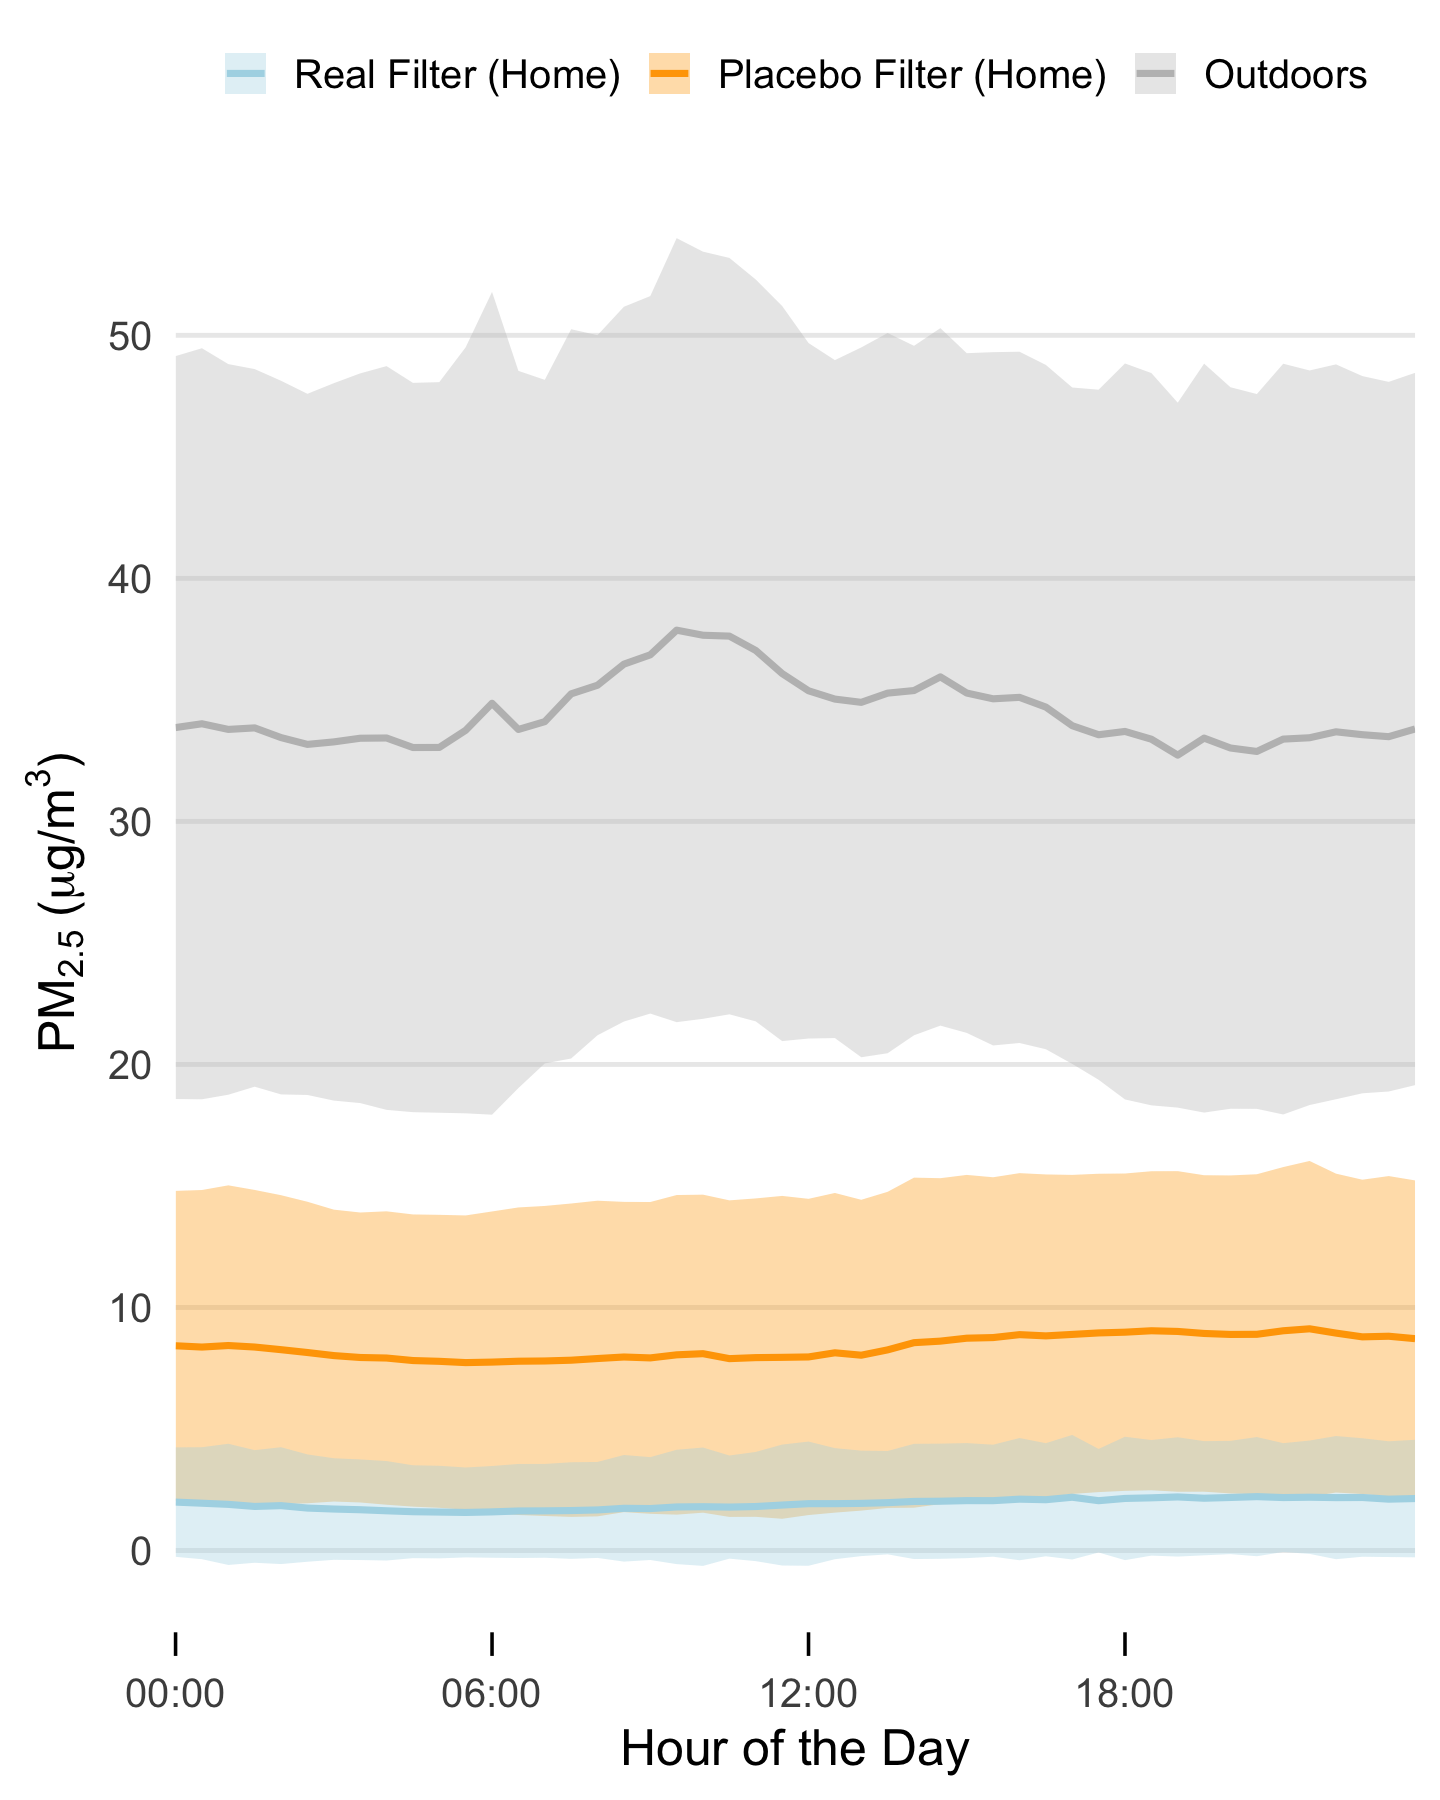

In [22]:
dimension <- plot_dimension(is_vertical = TRUE)

p <- ggplot(data_for_hourly_graph, aes(
  x = hour_minute,
  y = mean,
  color = treatment_for_plot,
  group = interaction(location_type, treatment_for_plot),
  fill = treatment_for_plot
)) +
  geom_ribbon(aes(ymin = mean - sd, ymax = mean + sd), alpha = 0.35, color = NA) +
  geom_line(size = 2) +
  scale_x_datetime(
    date_labels = "%H:%M",
    breaks = seq(
      from = min(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      to = max(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      by = "6 hours"
    ),
    limits = c(
      min(data_for_hourly_graph$hour_minute, na.rm = TRUE),
      max(data_for_hourly_graph$hour_minute, na.rm = TRUE)
    ),
    expand = c(0, 0)
  ) + scale_color_manual(
    values = TREATMENT_FILL_VALUES,
    labels = TREATMENT_LABELS_2,
    na.value = "gray"
  ) +
  scale_fill_manual(
    values = TREATMENT_FILL_VALUES,
    labels = TREATMENT_LABELS_2,
    na.value = "gray"
  ) +
  scale_y_continuous(
    breaks = sort(unique(c(
    seq(0, max(c(data_for_hourly_graph$mean + data_for_hourly_graph$sd), na.rm = TRUE), by = 10)
    )))
  ) +
  labs(
    x = "Hour of the Day",
    y = expression(PM[2.5] ~ "(" * mu * "g/m"^3 * ")"),
    color = NULL,
    fill = NULL
  ) +
  guides(
    color = guide_legend(order = 1, nrow = 1, reverse = TRUE),
    fill = guide_legend(order = 1, nrow = 1, reverse = TRUE),
    linetype = guide_legend(order = 2, ncol = 1)
  ) +
  theme_minimal(base_size = 30) +
  theme(
    axis.ticks.x = element_line(color = "black", size = 1),
    axis.ticks.length = unit(0.5, "cm"),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    plot.background = element_rect(fill = "transparent", color = NA),
    legend.key.size = unit(1, "cm"),
    legend.position = "top",
    legend.box = "vertical",
    legend.box.just  = "center",
    legend.spacing.x = unit(0, "cm"),
    legend.spacing.y = unit(0, "cm")
  )

dir.create(file.path("../visualization"), showWarnings = FALSE, recursive = TRUE)
options(repr.plot.width = dimension$width, repr.plot.height = dimension$height)

ggsave(
    filename = file.path("../visualization", 
        paste0(
            "pm25_hourly.pdf"
        )),
    plot = p,
    width = dimension$width,
    height = dimension$height,
    dpi = 300
)

p